In [0]:
volume_path = "/Volumes/databricks_milestone/default/retailanalytics"


In [0]:
customers_df = spark.read.option("header", True).option("inferSchema", True).csv(f"{volume_path}/customers.csv")
products_df = spark.read.option("header", True).option("inferSchema", True).csv(f"{volume_path}/products.csv")
orders_df = spark.read.option("header", True).option("inferSchema", True).csv(f"{volume_path}/orders.csv")
preferences_df = spark.read.option("multiline", True).json(f"{volume_path}/customer_preferences.json")

In [0]:
customers_df.printSchema()
products_df.printSchema()
orders_df.printSchema()
preferences_df.printSchema()

root
 |-- customer_id: string (nullable = true)
 |-- customer_name: string (nullable = true)
 |-- city: string (nullable = true)
 |-- state: string (nullable = true)
 |-- customer_type: string (nullable = true)

root
 |-- product_id: string (nullable = true)
 |-- product_name: string (nullable = true)
 |-- category: string (nullable = true)
 |-- unit_price: integer (nullable = true)

root
 |-- order_id: string (nullable = true)
 |-- customer_id: string (nullable = true)
 |-- product_id: string (nullable = true)
 |-- order_date: date (nullable = true)
 |-- quantity: integer (nullable = true)
 |-- status: string (nullable = true)

root
 |-- customer_id: string (nullable = true)
 |-- loyalty: struct (nullable = true)
 |    |-- points: long (nullable = true)
 |    |-- tier: string (nullable = true)
 |-- preferred_channel: string (nullable = true)



In [0]:
customers_df.display()
products_df.display()
orders_df.display()
preferences_df.display()

customer_id,customer_name,city,state,customer_type
C101,Rahul Sharma,Hyderabad,Telangana,Premium
C102,Priya Reddy,Bangalore,Karnataka,Regular
C103,Amit Kumar,Mumbai,Maharashtra,Regular
C104,Sneha Patel,Delhi,Delhi,Premium
C105,Farhan Ali,Chennai,Tamil Nadu,Regular
C106,Neha Singh,Pune,Maharashtra,Premium
C107,Arjun Verma,Hyderabad,Telangana,Regular
C108,Meera Nair,Kochi,Kerala,Premium


product_id,product_name,category,unit_price
P101,Laptop,Electronics,65000
P102,Mobile,Electronics,25000
P103,Chair,Furniture,7000
P104,Table,Furniture,12000
P105,Shoes,Fashion,4500
P106,Watch,Fashion,8000
P107,TV,Electronics,45000
P108,Bag,Fashion,3000


order_id,customer_id,product_id,order_date,quantity,status
O1001,C101,P101,2026-06-01,1,Completed
O1002,C102,P102,2026-06-01,2,Completed
O1003,C103,P103,2026-06-02,3,Pending
O1004,C104,P104,2026-06-02,2,Completed
O1005,C105,P105,2026-06-03,4,Cancelled
O1006,C106,P106,2026-06-03,1,Completed
O1007,C107,P107,2026-06-04,1,Completed
O1008,C108,P108,2026-06-04,5,Completed
O1009,C101,P102,2026-06-05,1,Completed
O1010,C104,P101,2026-06-05,1,Completed


customer_id,loyalty,preferred_channel
C101,"List(1200, Gold)",Online
C102,"List(700, Silver)",Store
C104,"List(2200, Platinum)",Online
C108,"List(1500, Gold)",Mobile App


In [0]:
spark.sql("CREATE SCHEMA IF NOT EXISTS databricks_milestone.retail_bronze")
spark.sql("CREATE SCHEMA IF NOT EXISTS databricks_milestone.retail_silver")
spark.sql("CREATE SCHEMA IF NOT EXISTS databricks_milestone.retail_gold")

DataFrame[]

In [0]:
customers_df.write.format("delta").mode("overwrite").saveAsTable("retail_bronze.customers_raw")
products_df.write.format("delta").mode("overwrite").saveAsTable("retail_bronze.products_raw")
orders_df.write.format("delta").mode("overwrite").saveAsTable("retail_bronze.orders_raw")
preferences_df.write.format("delta").mode("overwrite").saveAsTable("retail_bronze.preferences_raw")

In [0]:
from pyspark.sql.functions import col, when, month, year, concat_ws, lit, to_date
 
customers_clean = customers_df.dropna()
products_clean = products_df.dropna()
orders_clean = orders_df.dropna()
 
preferences_flat = preferences_df.select(
    col("customer_id"),
    col("preferred_channel"),
    col("loyalty.tier").alias("loyalty_tier"),
    col("loyalty.points").alias("loyalty_points")
)

In [0]:
customers_with_prefs = customers_clean.join(preferences_flat, on="customer_id", how="left")
 
orders_with_customers = orders_clean.join(customers_clean, on="customer_id", how="left")
 
orders_full = orders_with_customers.join(products_clean, on="product_id", how="left")

In [0]:
from pyspark.sql.functions import expr, date_format
 
orders_enriched = orders_full \
    .withColumn("revenue", col("quantity") * col("unit_price")) \
    .withColumn("order_month", date_format(to_date(col("order_date")), "yyyy-MM")) \
    .withColumn("customer_segment",
        when(col("customer_type") == "Premium", "High Value")
        .otherwise("Standard Value")
    )

In [0]:
orders_enriched.write.format("delta").mode("overwrite").saveAsTable("databricks_milestone.retail_silver.orders_enriched")
customers_with_prefs.write.format("delta").mode("overwrite").saveAsTable("databricks_milestone.retail_silver.customers_enriched")
products_clean.write.format("delta").mode("overwrite").saveAsTable("databricks_milestone.retail_silver.products_clean")

In [0]:
orders_enriched.createOrReplaceTempView("orders_view")
customers_with_prefs.createOrReplaceTempView("customers_view")
products_clean.createOrReplaceTempView("products_view")

In [0]:
total_revenue = spark.sql("""
    SELECT SUM(revenue) AS total_revenue
    FROM orders_view
""")
total_revenue.display()

total_revenue
336000


In [0]:
revenue_by_city = spark.sql("""
    SELECT city, SUM(revenue) AS total_revenue
    FROM orders_view
    GROUP BY city
    ORDER BY total_revenue DESC
""")
revenue_by_city.display()

city,total_revenue
Hyderabad,135000
Delhi,89000
Bangalore,50000
Mumbai,21000
Chennai,18000
Kochi,15000
Pune,8000


In [0]:
revenue_by_category = spark.sql("""
    SELECT category, SUM(revenue) AS total_revenue
    FROM orders_view
    GROUP BY category
    ORDER BY total_revenue DESC
""")
revenue_by_category.display()

category,total_revenue
Electronics,250000
Furniture,45000
Fashion,41000


In [0]:
top_customers = spark.sql("""
    SELECT customer_id, customer_name, SUM(revenue) AS total_revenue
    FROM orders_view
    GROUP BY customer_id, customer_name
    ORDER BY total_revenue DESC
""")
top_customers.display()

customer_id,customer_name,total_revenue
C101,Rahul Sharma,90000
C104,Sneha Patel,89000
C102,Priya Reddy,50000
C107,Arjun Verma,45000
C103,Amit Kumar,21000
C105,Farhan Ali,18000
C108,Meera Nair,15000
C106,Neha Singh,8000


In [0]:
completed_orders = spark.sql("""
    SELECT *
    FROM orders_view
    WHERE status = 'Completed'
""")
completed_orders.display()

product_id,customer_id,order_id,order_date,quantity,status,customer_name,city,state,customer_type,product_name,category,unit_price,revenue,order_month,customer_segment
P101,C101,O1001,2026-06-01,1,Completed,Rahul Sharma,Hyderabad,Telangana,Premium,Laptop,Electronics,65000,65000,2026-06,High Value
P102,C102,O1002,2026-06-01,2,Completed,Priya Reddy,Bangalore,Karnataka,Regular,Mobile,Electronics,25000,50000,2026-06,Standard Value
P104,C104,O1004,2026-06-02,2,Completed,Sneha Patel,Delhi,Delhi,Premium,Table,Furniture,12000,24000,2026-06,High Value
P106,C106,O1006,2026-06-03,1,Completed,Neha Singh,Pune,Maharashtra,Premium,Watch,Fashion,8000,8000,2026-06,High Value
P107,C107,O1007,2026-06-04,1,Completed,Arjun Verma,Hyderabad,Telangana,Regular,TV,Electronics,45000,45000,2026-06,Standard Value
P108,C108,O1008,2026-06-04,5,Completed,Meera Nair,Kochi,Kerala,Premium,Bag,Fashion,3000,15000,2026-06,High Value
P102,C101,O1009,2026-06-05,1,Completed,Rahul Sharma,Hyderabad,Telangana,Premium,Mobile,Electronics,25000,25000,2026-06,High Value
P101,C104,O1010,2026-06-05,1,Completed,Sneha Patel,Delhi,Delhi,Premium,Laptop,Electronics,65000,65000,2026-06,High Value


In [0]:
from pyspark.sql.window import Window
from pyspark.sql.functions import rank, dense_rank, sum as _sum
 
product_window = Window.orderBy(col("revenue").desc())
ranked_products = orders_enriched \
    .groupBy("product_id", "product_name", "category") \
    .agg(_sum("revenue").alias("total_revenue")) \
    .withColumn("rank", rank().over(Window.orderBy(col("total_revenue").desc())))
ranked_products.display()

/databricks/python/lib/python3.12/site-packages/pyspark/sql/connect/expressions.py:1160: UserWarning: WARN WindowExpression: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
  warnings.warn(


product_id,product_name,category,total_revenue,rank
P101,Laptop,Electronics,130000,1
P102,Mobile,Electronics,75000,2
P107,TV,Electronics,45000,3
P104,Table,Furniture,24000,4
P103,Chair,Furniture,21000,5
P105,Shoes,Fashion,18000,6
P108,Bag,Fashion,15000,7
P106,Watch,Fashion,8000,8


In [0]:
customer_window = Window.orderBy(col("total_revenue").desc())
ranked_customers = orders_enriched \
    .groupBy("customer_id", "customer_name") \
    .agg(_sum("revenue").alias("total_revenue")) \
    .withColumn("rank", rank().over(Window.orderBy(col("total_revenue").desc())))
ranked_customers.display()

/databricks/python/lib/python3.12/site-packages/pyspark/sql/connect/expressions.py:1160: UserWarning: WARN WindowExpression: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
  warnings.warn(
/databricks/python/lib/python3.12/site-packages/pyspark/sql/connect/expressions.py:1160: UserWarning: WARN WindowExpression: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
  warnings.warn(


customer_id,customer_name,total_revenue,rank
C101,Rahul Sharma,90000,1
C104,Sneha Patel,89000,2
C102,Priya Reddy,50000,3
C107,Arjun Verma,45000,4
C103,Amit Kumar,21000,5
C105,Farhan Ali,18000,6
C108,Meera Nair,15000,7
C106,Neha Singh,8000,8


In [0]:
top3_customers = ranked_customers.filter(col("rank") <= 3)
top3_customers.display()

/databricks/python/lib/python3.12/site-packages/pyspark/sql/connect/expressions.py:1160: UserWarning: WARN WindowExpression: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
  warnings.warn(
/databricks/python/lib/python3.12/site-packages/pyspark/sql/connect/expressions.py:1160: UserWarning: WARN WindowExpression: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
  warnings.warn(


customer_id,customer_name,total_revenue,rank
C101,Rahul Sharma,90000,1
C104,Sneha Patel,89000,2
C102,Priya Reddy,50000,3


In [0]:
category_window = Window.partitionBy("category").orderBy(col("total_revenue").desc())
top_product_per_category = orders_enriched \
    .groupBy("product_id", "product_name", "category") \
    .agg(_sum("revenue").alias("total_revenue")) \
    .withColumn("rank", rank().over(category_window)) \
    .filter(col("rank") == 1)
top_product_per_category.display()

product_id,product_name,category,total_revenue,rank
P101,Laptop,Electronics,130000,1
P105,Shoes,Fashion,18000,1
P104,Table,Furniture,24000,1


In [0]:
date_window = Window.orderBy("order_date").rowsBetween(Window.unboundedPreceding, Window.currentRow)
running_revenue = orders_enriched \
    .groupBy("order_date") \
    .agg(_sum("revenue").alias("daily_revenue")) \
    .withColumn("running_revenue", _sum("daily_revenue").over(date_window))
running_revenue.display()

/databricks/python/lib/python3.12/site-packages/pyspark/sql/connect/expressions.py:1160: UserWarning: WARN WindowExpression: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
  warnings.warn(


order_date,daily_revenue,running_revenue
2026-06-01,115000,115000
2026-06-02,45000,160000
2026-06-03,26000,186000
2026-06-04,60000,246000
2026-06-05,90000,336000


In [0]:
orders_enriched.write.format("delta").mode("overwrite").saveAsTable("databricks_milestone.retail_gold.orders_gold")
 
ranked_customers.write.format("delta").mode("overwrite").saveAsTable("databricks_milestone.retail_gold.customer_rankings")

/databricks/python/lib/python3.12/site-packages/pyspark/sql/connect/expressions.py:1160: UserWarning: WARN WindowExpression: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
  warnings.warn(


In [0]:
spark.sql("""
    CREATE TABLE IF NOT EXISTS databricks_milestone.retail_gold.product_revenue
    USING DELTA
    AS SELECT product_id, product_name, category, SUM(revenue) AS total_revenue
    FROM databricks_milestone.retail_silver.orders_enriched
    GROUP BY product_id, product_name, category
""")

DataFrame[num_affected_rows: bigint, num_inserted_rows: bigint]

In [0]:
spark.sql("DESCRIBE HISTORY databricks_milestone.retail_gold.orders_gold").display()


version,timestamp,userId,userName,operation,operationParameters,job,notebook,queryHistoryStatementId,clusterId,readVersion,isolationLevel,isBlindAppend,operationMetrics,userMetadata,engineInfo
0,2026-06-22T11:07:44.000Z,148655192397593,azuser7230_mml.local@karthikirisoutlook.onmicrosoft.com,CREATE OR REPLACE TABLE AS SELECT,"Map(isV1SaveAsTableOverwrite -> true, partitionBy -> [], clusterBy -> [], description -> null, isManaged -> true, properties -> {""delta.parquet.compression.codec"":""zstd"",""delta.enableDeletionVectors"":""true""}, statsOnLoad -> true)",null,List(490106471942206),b6905b4a-9abc-4d75-98cd-1800f40d976e,0622-101327-jooa2kzl-v2n,null,WriteSerializable,false,"Map(numFiles -> 1, numRemovedFiles -> 0, numRemovedBytes -> 0, numDeletionVectorsRemoved -> 0, numOutputRows -> 10, numOutputBytes -> 4978)",null,Databricks-Runtime/18.2.x-photon-scala2.13


In [0]:
spark.read.format("delta").option("versionAsOf", 0).table("databricks_milestone.retail_gold.orders_gold").display()

product_id,customer_id,order_id,order_date,quantity,status,customer_name,city,state,customer_type,product_name,category,unit_price,revenue,order_month,customer_segment
P101,C101,O1001,2026-06-01,1,Completed,Rahul Sharma,Hyderabad,Telangana,Premium,Laptop,Electronics,65000,65000,2026-06,High Value
P102,C102,O1002,2026-06-01,2,Completed,Priya Reddy,Bangalore,Karnataka,Regular,Mobile,Electronics,25000,50000,2026-06,Standard Value
P103,C103,O1003,2026-06-02,3,Pending,Amit Kumar,Mumbai,Maharashtra,Regular,Chair,Furniture,7000,21000,2026-06,Standard Value
P104,C104,O1004,2026-06-02,2,Completed,Sneha Patel,Delhi,Delhi,Premium,Table,Furniture,12000,24000,2026-06,High Value
P105,C105,O1005,2026-06-03,4,Cancelled,Farhan Ali,Chennai,Tamil Nadu,Regular,Shoes,Fashion,4500,18000,2026-06,Standard Value
P106,C106,O1006,2026-06-03,1,Completed,Neha Singh,Pune,Maharashtra,Premium,Watch,Fashion,8000,8000,2026-06,High Value
P107,C107,O1007,2026-06-04,1,Completed,Arjun Verma,Hyderabad,Telangana,Regular,TV,Electronics,45000,45000,2026-06,Standard Value
P108,C108,O1008,2026-06-04,5,Completed,Meera Nair,Kochi,Kerala,Premium,Bag,Fashion,3000,15000,2026-06,High Value
P102,C101,O1009,2026-06-05,1,Completed,Rahul Sharma,Hyderabad,Telangana,Premium,Mobile,Electronics,25000,25000,2026-06,High Value
P101,C104,O1010,2026-06-05,1,Completed,Sneha Patel,Delhi,Delhi,Premium,Laptop,Electronics,65000,65000,2026-06,High Value


In [0]:
updated_customers = spark.createDataFrame([
    ("C101", "Rahul Sharma", "Hyderabad", "Telangana", "Premium"),
    ("C109", "New Customer", "Chennai", "Tamil Nadu", "Regular")
], ["customer_id", "customer_name", "city", "state", "customer_type"])

In [0]:
delta_customers = DeltaTable.forName(spark, "databricks_milestone.retail_silver.customers_enriched")
 
delta_customers.alias("target").merge(
    updated_customers.alias("source"),
    "target.customer_id = source.customer_id"
).whenMatchedUpdate(set={
    "customer_name": "source.customer_name",
    "city": "source.city",
    "state": "source.state",
    "customer_type": "source.customer_type"
}).whenNotMatchedInsert(values={
    "customer_id": "source.customer_id",
    "customer_name": "source.customer_name",
    "city": "source.city",
    "state": "source.state",
    "customer_type": "source.customer_type",
    "preferred_channel": "null",
    "loyalty_tier": "null",
    "loyalty_points": "null"
}).execute()

DataFrame[num_affected_rows: bigint, num_updated_rows: bigint, num_deleted_rows: bigint, num_inserted_rows: bigint]

In [0]:
spark.sql("DESCRIBE HISTORY databricks_milestone.retail_silver.customers_enriched").display()


version,timestamp,userId,userName,operation,operationParameters,job,notebook,queryHistoryStatementId,clusterId,readVersion,isolationLevel,isBlindAppend,operationMetrics,userMetadata,engineInfo
0,2026-06-22T11:00:11.000Z,148655192397593,azuser7230_mml.local@karthikirisoutlook.onmicrosoft.com,CREATE OR REPLACE TABLE AS SELECT,"Map(isV1SaveAsTableOverwrite -> true, partitionBy -> [], clusterBy -> [], description -> null, isManaged -> true, properties -> {""delta.parquet.compression.codec"":""zstd"",""delta.enableDeletionVectors"":""true""}, statsOnLoad -> true)",null,List(490106471942206),8cc5a9aa-8743-4aa0-8a33-8b67cdc19633,0622-101327-jooa2kzl-v2n,null,WriteSerializable,false,"Map(numFiles -> 1, numRemovedFiles -> 0, numRemovedBytes -> 0, numDeletionVectorsRemoved -> 0, numOutputRows -> 8, numOutputBytes -> 2697)",null,Databricks-Runtime/18.2.x-photon-scala2.13


In [0]:
spark.sql("OPTIMIZE databricks_milestone.retail_gold.orders_gold ZORDER BY (city)")


DataFrame[path: string, metrics: struct<numFilesAdded:bigint,numFilesRemoved:bigint,filesAdded:struct<min:bigint,max:bigint,avg:double,totalFiles:bigint,totalSize:bigint>,filesRemoved:struct<min:bigint,max:bigint,avg:double,totalFiles:bigint,totalSize:bigint>,partitionsOptimized:bigint,zOrderStats:struct<strategyName:string,inputCubeFiles:struct<num:bigint,size:bigint>,inputOtherFiles:struct<num:bigint,size:bigint>,inputNumCubes:bigint,mergedFiles:struct<num:bigint,size:bigint>,numOutputCubes:bigint,mergedNumCubes:bigint>,clusteringStats:struct<inputZCubeFiles:struct<numFiles:bigint,size:bigint>,inputOtherFiles:struct<numFiles:bigint,size:bigint>,inputNumZCubes:bigint,mergedFiles:struct<numFiles:bigint,size:bigint>,numOutputZCubes:bigint>,numBins:bigint,numBatches:bigint,totalConsideredFiles:bigint,totalFilesSkipped:bigint,preserveInsertionOrder:boolean,numFilesSkippedToReduceWriteAmplification:bigint,numBytesSkippedToReduceWriteAmplification:bigint,startTimeMs:bigint,endTimeMs:bigint,

In [0]:
spark.sql(f"VACUUM databricks_milestone.retail_gold.orders_gold RETAIN 168 HOURS")


DataFrame[path: string]

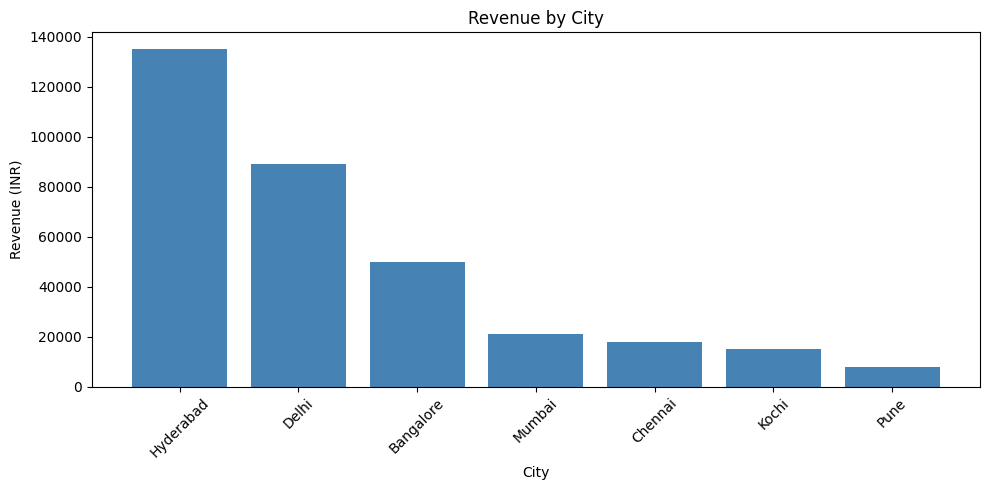

---------------------------------------------------------------------------
FileNotFoundError                         Traceback (most recent call last)
File <command-8412567044567184>, line 12
     10 plt.xticks(rotation=45)
     11 plt.tight_layout()
---> 12 plt.savefig(f"{volume_path}/charts/revenue_by_city.png")
     13 plt.show()

File /databricks/python/lib/python3.12/site-packages/matplotlib/pyplot.py:1243, in savefig(*args, **kwargs)
   1240 fig = gcf()
   1241 # savefig default implementation has no return, so mypy is unhappy
   1242 # presumably this is here because subclasses can return?
-> 1243 res = fig.savefig(*args, **kwargs)  # type: ignore[func-returns-value]
   1244 fig.canvas.draw_idle()  # Need this if 'transparent=True', to reset colors.
   1245 return res

File /databricks/python/lib/python3.12/site-packages/matplotlib/figure.py:3490, in Figure.savefig(self, fname, transparent, **kwargs)
   3488     for ax in self.axes:
   3489         _recursively_make_axes_transp

In [0]:
import pandas as pd
import matplotlib.pyplot as plt
 
city_pd = revenue_by_city.toPandas()
fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(city_pd["city"], city_pd["total_revenue"], color="steelblue")
ax.set_title("Revenue by City")
ax.set_xlabel("City")
ax.set_ylabel("Revenue (INR)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(f"{volume_path}/charts/revenue_by_city.png")
plt.show()

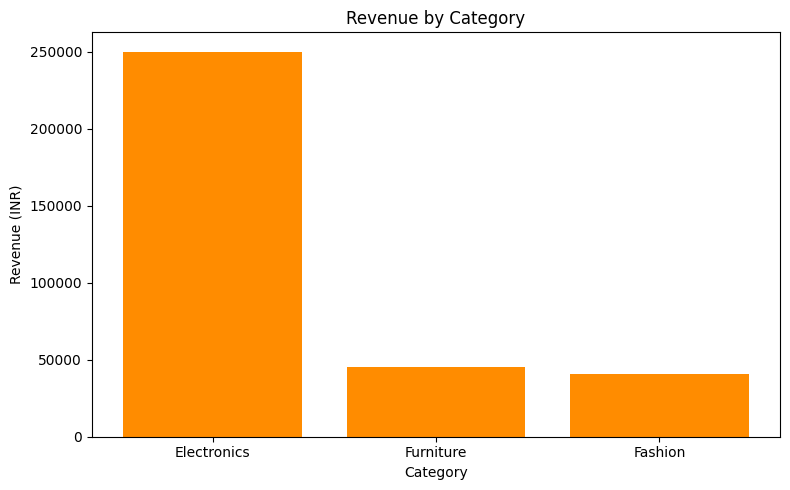

---------------------------------------------------------------------------
FileNotFoundError                         Traceback (most recent call last)
File <command-8412567044567185>, line 8
      6 ax.set_ylabel("Revenue (INR)")
      7 plt.tight_layout()
----> 8 plt.savefig(f"{volume_path}/charts/revenue_by_category.png")
      9 plt.show()

File /databricks/python/lib/python3.12/site-packages/matplotlib/pyplot.py:1243, in savefig(*args, **kwargs)
   1240 fig = gcf()
   1241 # savefig default implementation has no return, so mypy is unhappy
   1242 # presumably this is here because subclasses can return?
-> 1243 res = fig.savefig(*args, **kwargs)  # type: ignore[func-returns-value]
   1244 fig.canvas.draw_idle()  # Need this if 'transparent=True', to reset colors.
   1245 return res

File /databricks/python/lib/python3.12/site-packages/matplotlib/figure.py:3490, in Figure.savefig(self, fname, transparent, **kwargs)
   3488     for ax in self.axes:
   3489         _recursively_make_a

In [0]:
cat_pd = revenue_by_category.toPandas()
fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(cat_pd["category"], cat_pd["total_revenue"], color="darkorange")
ax.set_title("Revenue by Category")
ax.set_xlabel("Category")
ax.set_ylabel("Revenue (INR)")
plt.tight_layout()
plt.savefig(f"{volume_path}/charts/revenue_by_category.png")
plt.show()

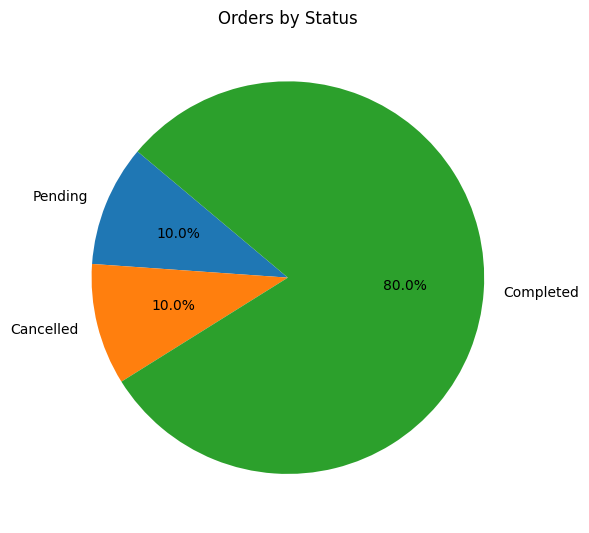

---------------------------------------------------------------------------
FileNotFoundError                         Traceback (most recent call last)
File <command-8412567044567186>, line 6
      4 ax.set_title("Orders by Status")
      5 plt.tight_layout()
----> 6 plt.savefig(f"{volume_path}/charts/orders_by_status.png")
      7 plt.show()

File /databricks/python/lib/python3.12/site-packages/matplotlib/pyplot.py:1243, in savefig(*args, **kwargs)
   1240 fig = gcf()
   1241 # savefig default implementation has no return, so mypy is unhappy
   1242 # presumably this is here because subclasses can return?
-> 1243 res = fig.savefig(*args, **kwargs)  # type: ignore[func-returns-value]
   1244 fig.canvas.draw_idle()  # Need this if 'transparent=True', to reset colors.
   1245 return res

File /databricks/python/lib/python3.12/site-packages/matplotlib/figure.py:3490, in Figure.savefig(self, fname, transparent, **kwargs)
   3488     for ax in self.axes:
   3489         _recursively_make_ax

In [0]:
status_pd = orders_enriched.groupBy("status").count().toPandas()
fig, ax = plt.subplots(figsize=(6, 6))
ax.pie(status_pd["count"], labels=status_pd["status"], autopct="%1.1f%%", startangle=140)
ax.set_title("Orders by Status")
plt.tight_layout()
plt.savefig(f"{volume_path}/charts/orders_by_status.png")
plt.show()

/databricks/python/lib/python3.12/site-packages/pyspark/sql/connect/expressions.py:1160: UserWarning: WARN WindowExpression: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
  warnings.warn(


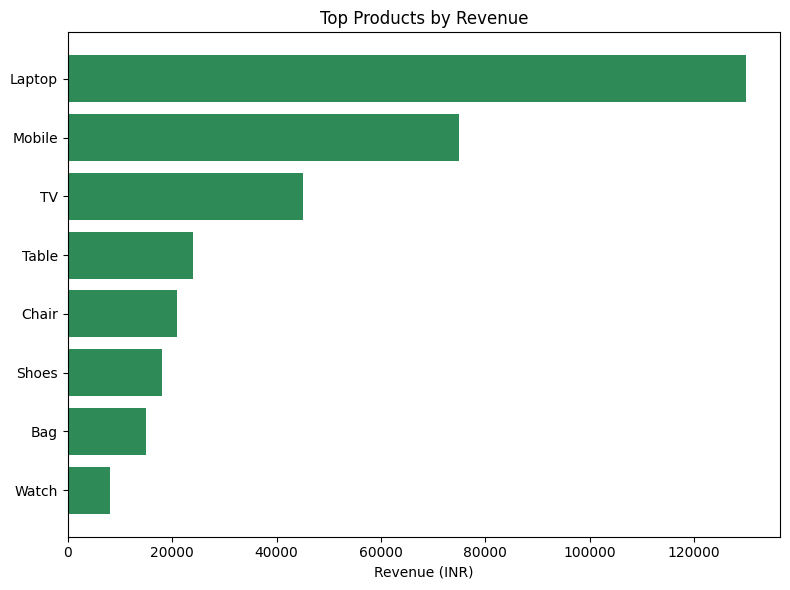

---------------------------------------------------------------------------
FileNotFoundError                         Traceback (most recent call last)
File <command-8412567044567187>, line 7
      5 ax.set_xlabel("Revenue (INR)")
      6 plt.tight_layout()
----> 7 plt.savefig(f"{volume_path}/charts/top_products.png")
      8 plt.show()

File /databricks/python/lib/python3.12/site-packages/matplotlib/pyplot.py:1243, in savefig(*args, **kwargs)
   1240 fig = gcf()
   1241 # savefig default implementation has no return, so mypy is unhappy
   1242 # presumably this is here because subclasses can return?
-> 1243 res = fig.savefig(*args, **kwargs)  # type: ignore[func-returns-value]
   1244 fig.canvas.draw_idle()  # Need this if 'transparent=True', to reset colors.
   1245 return res

File /databricks/python/lib/python3.12/site-packages/matplotlib/figure.py:3490, in Figure.savefig(self, fname, transparent, **kwargs)
   3488     for ax in self.axes:
   3489         _recursively_make_axes_tra

In [0]:
prod_pd = ranked_products.toPandas().sort_values("total_revenue")
fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(prod_pd["product_name"], prod_pd["total_revenue"], color="seagreen")
ax.set_title("Top Products by Revenue")
ax.set_xlabel("Revenue (INR)")
plt.tight_layout()
plt.savefig(f"{volume_path}/charts/top_products.png")
plt.show()

/databricks/python/lib/python3.12/site-packages/pyspark/sql/connect/expressions.py:1160: UserWarning: WARN WindowExpression: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
  warnings.warn(


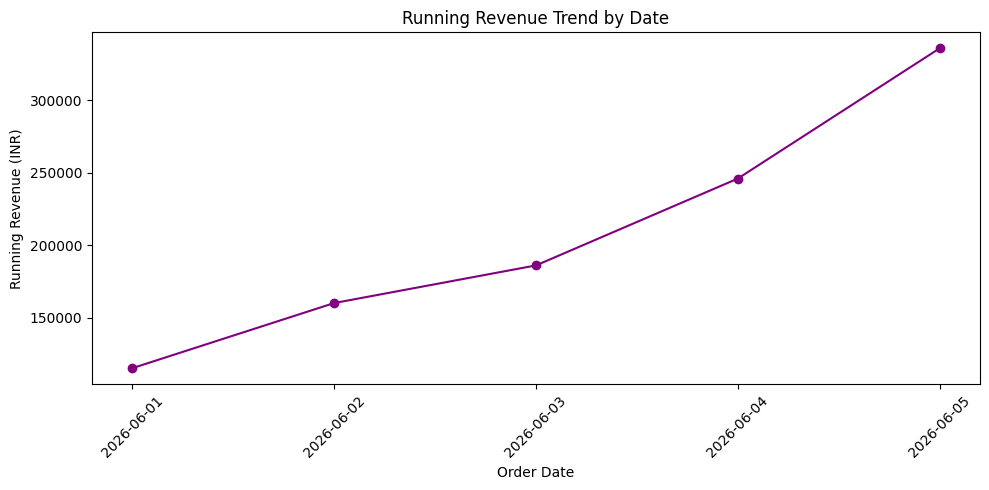

---------------------------------------------------------------------------
FileNotFoundError                         Traceback (most recent call last)
File <command-8412567044567188>, line 9
      7 plt.xticks(rotation=45)
      8 plt.tight_layout()
----> 9 plt.savefig(f"{volume_path}/charts/revenue_trend.png")
     10 plt.show()

File /databricks/python/lib/python3.12/site-packages/matplotlib/pyplot.py:1243, in savefig(*args, **kwargs)
   1240 fig = gcf()
   1241 # savefig default implementation has no return, so mypy is unhappy
   1242 # presumably this is here because subclasses can return?
-> 1243 res = fig.savefig(*args, **kwargs)  # type: ignore[func-returns-value]
   1244 fig.canvas.draw_idle()  # Need this if 'transparent=True', to reset colors.
   1245 return res

File /databricks/python/lib/python3.12/site-packages/matplotlib/figure.py:3490, in Figure.savefig(self, fname, transparent, **kwargs)
   3488     for ax in self.axes:
   3489         _recursively_make_axes_transpare

In [0]:
date_pd = running_revenue.orderBy("order_date").toPandas()
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(date_pd["order_date"].astype(str), date_pd["running_revenue"], marker="o", color="purple")
ax.set_title("Running Revenue Trend by Date")
ax.set_xlabel("Order Date")
ax.set_ylabel("Running Revenue (INR)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(f"{volume_path}/charts/revenue_trend.png")
plt.show()

In [0]:
spark.sql("""
    CREATE TABLE IF NOT EXISTS databricks_milestone.retail_gold.managed_orders
    USING DELTA
    AS SELECT * FROM databricks_milestone.retail_gold.orders_gold
""")

DataFrame[num_affected_rows: bigint, num_inserted_rows: bigint]

In [0]:
spark.sql("""
    CREATE TABLE IF NOT EXISTS databricks_milestone.retail_gold.external_orders
    USING DELTA
    AS SELECT * FROM databricks_milestone.retail_gold.orders_gold
""")

DataFrame[num_affected_rows: bigint, num_inserted_rows: bigint]

In [0]:
orders_enriched.createOrReplaceTempView("temp_orders_view")
 
# orders_enriched.createOrReplaceGlobalTempView("global_orders_view")

In [0]:
spark.sql("SELECT * FROM temp_orders_view LIMIT 5").display()

product_id,customer_id,order_id,order_date,quantity,status,customer_name,city,state,customer_type,product_name,category,unit_price,revenue,order_month,customer_segment
P101,C101,O1001,2026-06-01,1,Completed,Rahul Sharma,Hyderabad,Telangana,Premium,Laptop,Electronics,65000,65000,2026-06,High Value
P102,C102,O1002,2026-06-01,2,Completed,Priya Reddy,Bangalore,Karnataka,Regular,Mobile,Electronics,25000,50000,2026-06,Standard Value
P103,C103,O1003,2026-06-02,3,Pending,Amit Kumar,Mumbai,Maharashtra,Regular,Chair,Furniture,7000,21000,2026-06,Standard Value
P104,C104,O1004,2026-06-02,2,Completed,Sneha Patel,Delhi,Delhi,Premium,Table,Furniture,12000,24000,2026-06,High Value
P105,C105,O1005,2026-06-03,4,Cancelled,Farhan Ali,Chennai,Tamil Nadu,Regular,Shoes,Fashion,4500,18000,2026-06,Standard Value


In [0]:
# spark.sql("SELECT * FROM global_temp.global_orders_view LIMIT 5").display()